In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [127]:
import warnings
warnings.filterwarnings('ignore')

In [128]:
df = pd.read_csv('Bank_Customer_Churn_Prediction.csv')

In [129]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [130]:
df

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [131]:
df.shape

(10000, 12)

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [133]:
df.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [134]:
df['churn'].value_counts()

churn
0    7963
1    2037
Name: count, dtype: int64

In [135]:
df['credit_card'].value_counts()

credit_card
1    7055
0    2945
Name: count, dtype: int64

In [136]:
df['active_member'].value_counts()

active_member
1    5151
0    4849
Name: count, dtype: int64

In [137]:
df['products_number'].value_counts()

products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [138]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
credit_score,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
products_number,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
credit_card,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
active_member,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48
churn,10000.0,2.037000e-01,0.402769,0.00,0.00,0.000000e+00,0.000000e+00,1.00


### Handle Outliers

In [139]:
cols = ['age', 'estimated_salary', 'balance', 'credit_score']

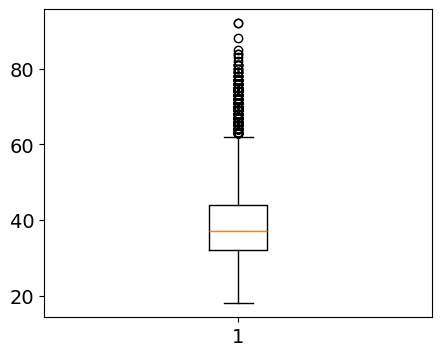

In [140]:
plt.figure(figsize=(5, 4))
plt.boxplot(x=df['age'])
plt.show()

In [141]:
age = df['age'].to_list()

In [142]:
Q1 = np.percentile(age, 25, method='midpoint')
Q2 = np.percentile(age, 50, method='midpoint')
Q3 = np.percentile(age, 75, method='midpoint')

In [143]:
IQR = Q3 - Q1

In [144]:
print(IQR)

12.0


In [145]:
print("Age Outliers :")
print('Minimum :', Q1 - 1.5*IQR)
print('Maximum :', Q3 + 1.5*IQR)


Age Outliers :
Minimum : 14.0
Maximum : 62.0


In [146]:
outliers_age = []
for i in age:
    if i > Q3 + 1.5 * IQR or i < Q1 - 1.5 * IQR:
        outliers_age.append(i)

print(outliers_age)

[66, 75, 65, 73, 65, 72, 67, 67, 79, 80, 68, 75, 66, 66, 70, 63, 72, 64, 64, 70, 67, 82, 63, 69, 65, 69, 64, 65, 74, 67, 66, 67, 63, 70, 71, 72, 67, 74, 76, 66, 63, 66, 68, 67, 63, 71, 66, 69, 73, 65, 66, 64, 69, 64, 77, 74, 65, 70, 67, 69, 67, 74, 69, 74, 74, 64, 63, 63, 70, 74, 65, 72, 77, 66, 65, 74, 88, 63, 71, 63, 64, 67, 70, 68, 72, 71, 66, 75, 67, 73, 69, 76, 63, 85, 67, 74, 76, 66, 69, 66, 72, 63, 71, 63, 74, 67, 72, 72, 66, 84, 71, 66, 63, 74, 69, 84, 67, 64, 68, 66, 77, 70, 67, 79, 67, 76, 73, 66, 67, 64, 73, 76, 72, 64, 71, 63, 70, 65, 66, 65, 80, 66, 63, 63, 63, 63, 66, 74, 69, 63, 64, 76, 75, 68, 69, 77, 64, 66, 74, 71, 67, 68, 64, 68, 70, 64, 75, 66, 64, 78, 65, 74, 64, 64, 71, 77, 79, 70, 81, 64, 68, 68, 63, 79, 66, 64, 70, 69, 71, 72, 66, 68, 63, 71, 72, 72, 64, 78, 75, 65, 65, 67, 63, 68, 71, 73, 64, 66, 71, 69, 71, 66, 76, 69, 73, 64, 64, 75, 73, 71, 72, 63, 67, 68, 73, 67, 64, 63, 92, 65, 75, 67, 71, 64, 66, 64, 66, 67, 77, 92, 67, 63, 66, 66, 68, 65, 72, 71, 76, 63,

In [147]:
df[df['age'].isin(outliers_age)]

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
58,15623944,511,Spain,Female,66,4,0.00,1,1,0,1643.11,1
85,15805254,652,Spain,Female,75,10,0.00,2,1,1,114675.75,0
104,15804919,670,Spain,Female,65,1,0.00,1,1,1,177655.68,1
158,15589975,646,France,Female,73,6,97259.25,1,0,1,104719.66,0
181,15789669,510,France,Male,65,2,0.00,2,1,1,48071.61,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9753,15705174,656,Germany,Male,68,7,153545.11,1,1,1,186574.68,0
9765,15777067,445,France,Male,64,2,136770.67,1,0,1,43678.06,0
9832,15814690,595,Germany,Female,64,2,105736.32,1,1,1,89935.73,1
9894,15704795,521,France,Female,77,6,0.00,2,1,1,49054.10,0


In [148]:
df = df[~df['age'].isin(outliers_age)]

In [149]:
# the outliers age does not follow any trend and does not relation with our target so we drop it

In [150]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,9641.0,1.569091e+07,71846.669981,15565701.00,15628420.00,15691004.00,15752953.00,15815690.00
credit_score,9641.0,6.502876e+02,96.691920,350.00,583.00,652.00,717.00,850.00
age,9641.0,3.779172e+01,8.803124,18.00,32.00,37.00,43.00,62.00
tenure,9641.0,5.015351e+00,2.888878,0.00,3.00,5.00,7.00,10.00
balance,9641.0,7.656067e+04,62401.698405,0.00,0.00,97318.25,127660.46,250898.09
products_number,9641.0,1.530962e+00,0.581617,1.00,1.00,1.00,2.00,4.00
credit_card,9641.0,7.052173e-01,0.455969,0.00,0.00,1.00,1.00,1.00
active_member,9641.0,5.031636e-01,0.500016,0.00,0.00,1.00,1.00,1.00
estimated_salary,9641.0,1.001724e+05,57512.265414,11.58,51113.14,100324.01,149458.73,199992.48
churn,9641.0,2.037133e-01,0.402779,0.00,0.00,0.00,0.00,1.00


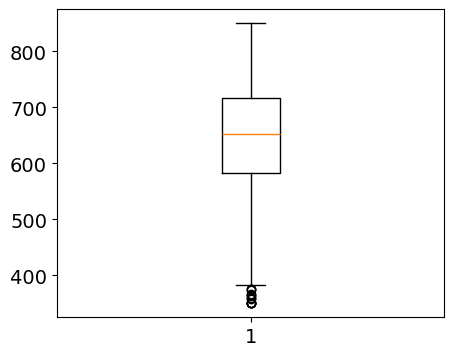

In [151]:
plt.figure(figsize=(5, 4))
plt.boxplot(x=df['credit_score'])
plt.show()

In [152]:
credit_score = df['credit_score'].to_list()

In [153]:
Q1_cr = np.percentile(credit_score, 25, method='midpoint')
Q2_cr = np.percentile(credit_score, 50, method='midpoint')
Q3_cr = np.percentile(credit_score, 75, method='midpoint')

In [154]:
IQR_cr = Q3_cr - Q1_cr
print(IQR_cr)

134.0


In [155]:
print("Credit Score Outliers :")
print('Minimum :', Q1_cr - 1.5*IQR_cr)
print('Maximum :', Q3_cr + 1.5*IQR_cr)

Credit Score Outliers :
Minimum : 382.0
Maximum : 918.0


In [156]:
outliers_credit_score = []
for i in credit_score:
    if i > Q3_cr + 1.5 * IQR_cr or i < Q1_cr - 1.5 * IQR_cr:
        outliers_credit_score.append(i)

print(outliers_credit_score)

[376, 376, 363, 359, 350, 350, 358, 351, 365, 367, 350, 350, 373, 350]


In [157]:
df[df['credit_score'].isin(outliers_credit_score)]

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
942,15804586,376,France,Female,46,6,0.00,1,1,0,157333.69,1
1193,15779947,363,Spain,Female,28,6,146098.43,3,1,0,100615.14,1
1405,15612494,359,France,Female,44,6,128747.69,1,1,0,146955.71,1
1631,15685372,350,Spain,Male,54,1,152677.48,1,1,1,191973.49,1
1838,15758813,350,Germany,Male,39,0,109733.20,2,0,0,123602.11,1
1962,15692416,358,Spain,Female,52,8,143542.36,3,1,0,141959.11,1
2473,15679249,351,Germany,Female,57,4,163146.46,1,1,0,169621.69,1
2579,15597896,365,Germany,Male,30,0,127760.07,1,1,0,81537.85,1
8154,15791533,367,Spain,Male,42,6,93608.28,1,1,0,168816.73,1


In [158]:
# credit score is related to our target so we cannot drop it

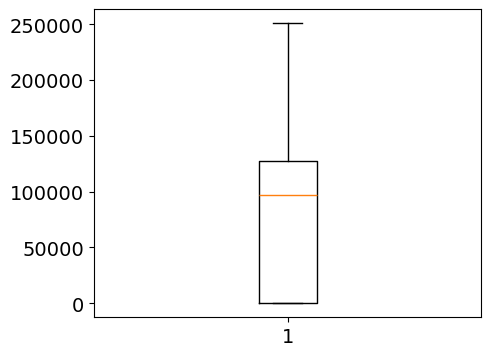

In [159]:
plt.figure(figsize=(5, 4))
plt.boxplot(x=df['balance'])
plt.show()

In [160]:
balance = df['balance'].to_list()

In [161]:
Q1_bal = np.percentile(balance, 25, method='midpoint')
Q2_bal = np.percentile(balance, 50, method='midpoint')
Q3_bal = np.percentile(balance, 75, method='midpoint')

In [162]:
IQR_bal = Q3_bal - Q1_bal
print(IQR_bal)

127660.46


In [163]:
print("Balance Outliers :")
print('Minimum :', Q1_bal - 1.5*IQR_bal)
print('Maximum :', Q3_bal + 1.5*IQR_bal)

Balance Outliers :
Minimum : -191490.69
Maximum : 319151.15


In [164]:
outliers_balance = []
for i in balance:
    if i > Q3_bal + 1.5 * IQR_bal or i < Q1_bal - 1.5 * IQR_bal:
        outliers_balance.append(i)

print(outliers_balance)

[]


In [165]:
# Balance does not have outlier

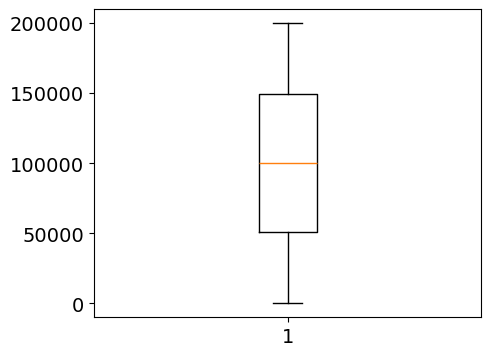

In [166]:
plt.figure(figsize=(5, 4))
plt.boxplot(x=df['estimated_salary'])
plt.show()

In [167]:
estimated_salary = df['estimated_salary'].to_list()

In [168]:
Q1_es = np.percentile(estimated_salary, 25, method='midpoint')
Q2_es = np.percentile(estimated_salary, 50, method='midpoint')
Q3_es = np.percentile(estimated_salary, 75, method='midpoint')

In [169]:
IQR_es = Q3_es - Q1_es
print(IQR_es)

98345.59000000001


In [170]:
print("Estimated Salary Outliers :")
print('Minimum :', Q1_es - 1.5*IQR_es)
print('Maximum :', Q3_es + 1.5*IQR_es)

Estimated Salary Outliers :
Minimum : -96405.24500000001
Maximum : 296977.115


In [171]:
outliers_es = []
for i in estimated_salary:
    if i > Q3_es + 1.5 * IQR_es or i < Q1_es - 1.5 * IQR_es:
        outliers_es.append(i)

print(outliers_es)

[]


In [172]:
# Estimated salary does not outliers

In [173]:
df.dtypes

customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

In [174]:
df.columns


Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [175]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Visualization

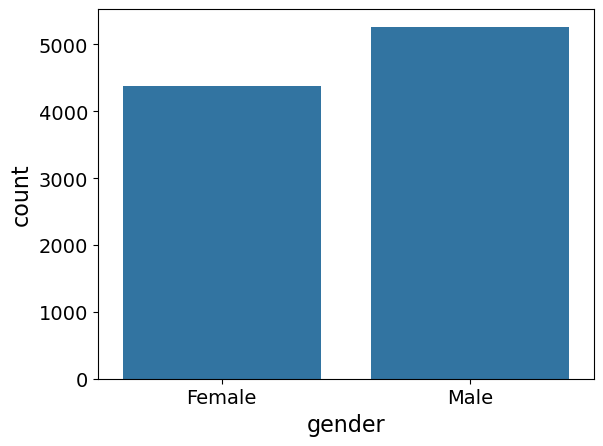

In [176]:
sns.countplot(data= df, x = 'gender')
plt.show()

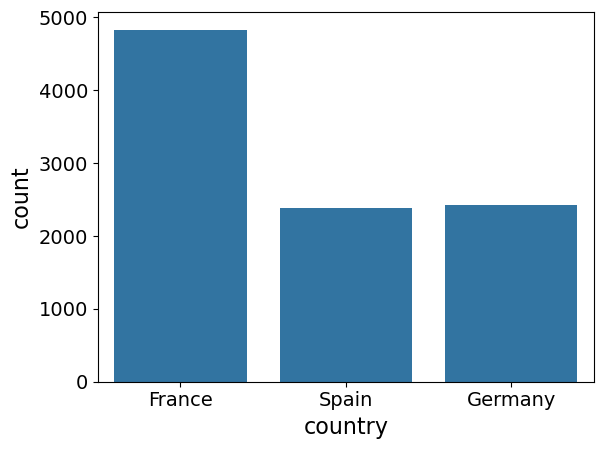

In [177]:
sns.countplot(data= df, x = 'country')
plt.show()

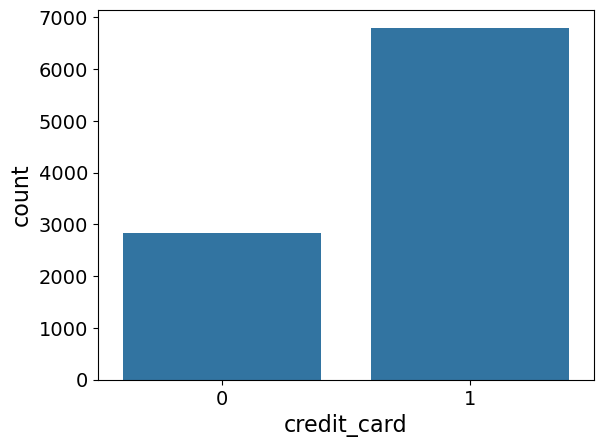

In [178]:
sns.countplot(data= df, x = 'credit_card')
plt.show()

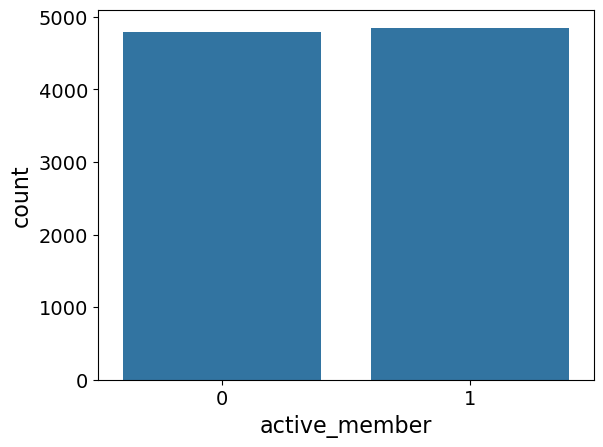

In [179]:
sns.countplot(data= df, x = 'active_member')
plt.show()

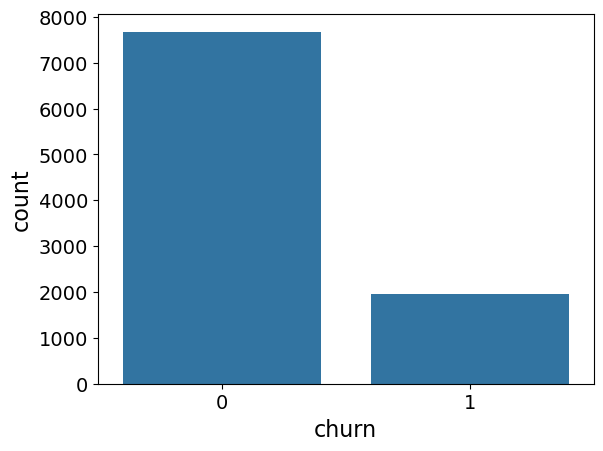

In [180]:
sns.countplot(data= df, x = 'churn')
plt.show()

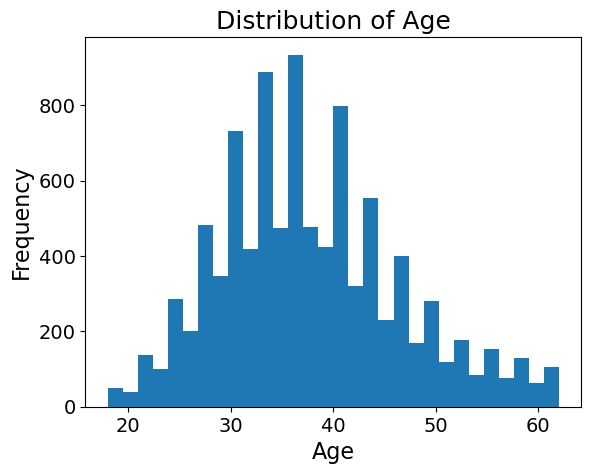

In [181]:
plt.hist(df['age'], bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

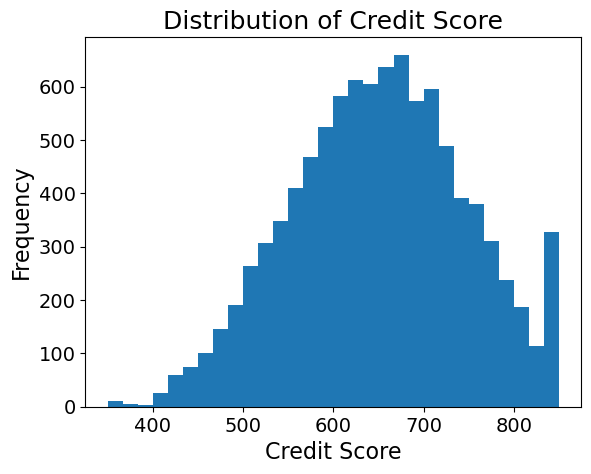

In [182]:
plt.hist(df['credit_score'], bins=30)
plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.show()

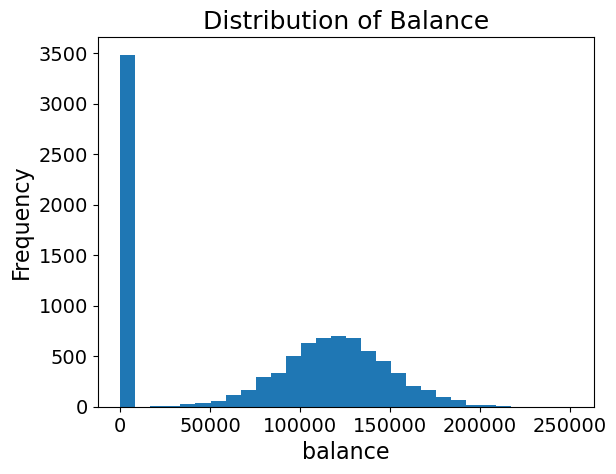

In [183]:
plt.hist(df['balance'], bins=30)
plt.title('Distribution of Balance')
plt.xlabel('balance')
plt.ylabel('Frequency')
plt.show()

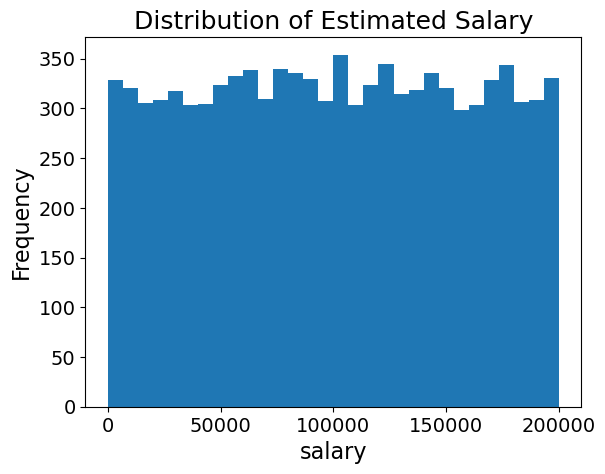

In [184]:
plt.hist(df['estimated_salary'], bins=30)
plt.title('Distribution of Estimated Salary')
plt.xlabel('salary')
plt.ylabel('Frequency')
plt.show()

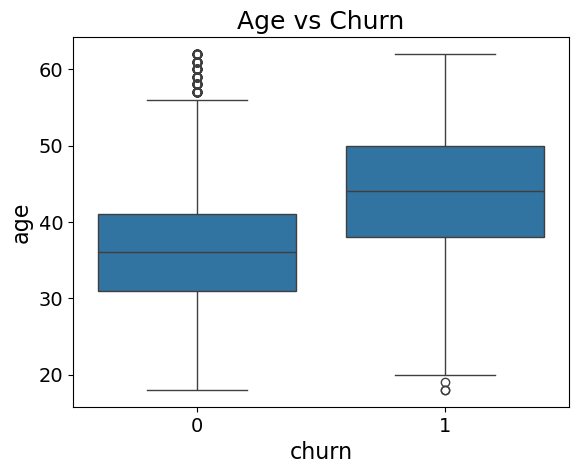

In [185]:
sns.boxplot(x= 'churn', y='age', data=df)
plt.title('Age vs Churn')
plt.show()

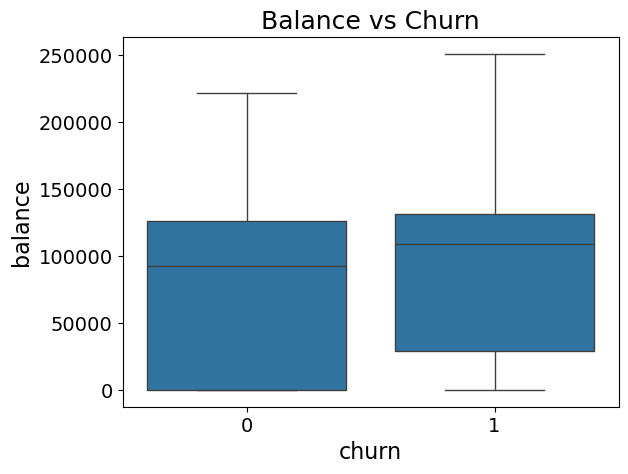

In [186]:
sns.boxplot(x ='churn', y ='balance', data=df)
plt.title('Balance vs Churn')
plt.show()

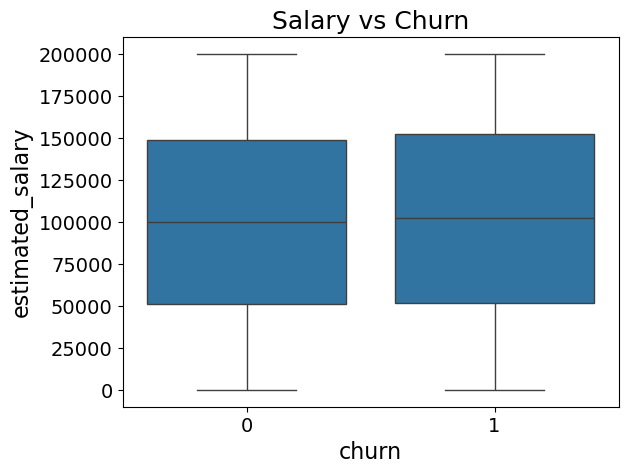

In [187]:
sns.boxplot(x= 'churn', y='estimated_salary', data=df)
plt.title('Salary vs Churn')
plt.show()

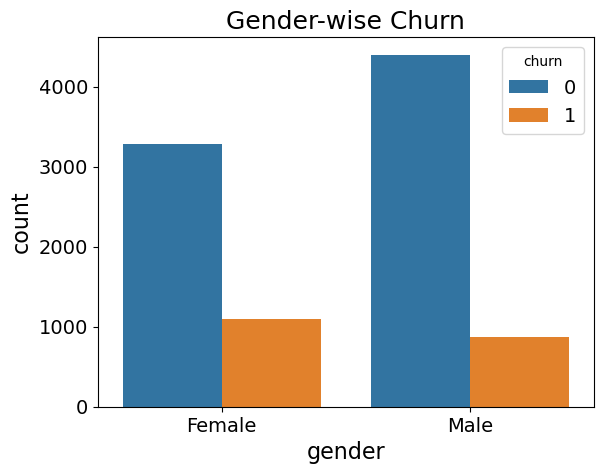

In [188]:
sns.countplot(data=df, x ='gender', hue ='churn')
plt.title('Gender-wise Churn')
plt.show()

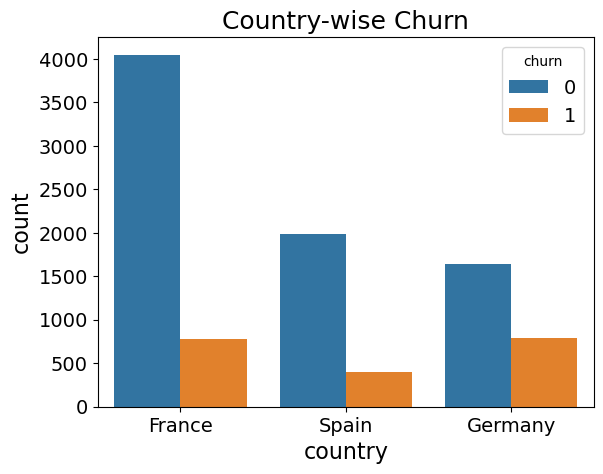

In [189]:
sns.countplot(data=df, x ='country', hue ='churn')
plt.title('Country-wise Churn')
plt.show()

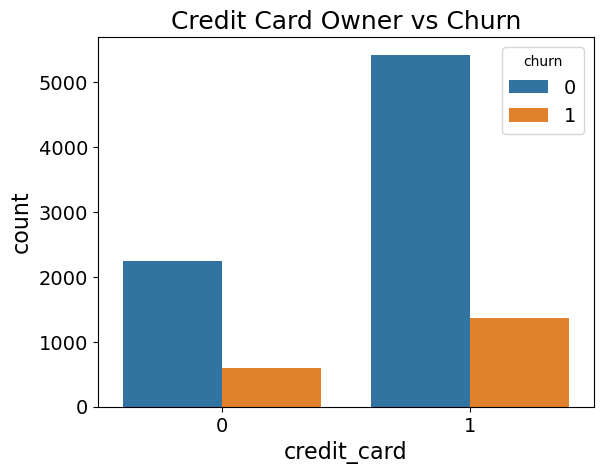

In [190]:
sns.countplot(data=df, x ='credit_card', hue ='churn')
plt.title('Credit Card Owner vs Churn')
plt.show()

In [191]:
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [192]:
df.drop(['customer_id'], axis=1, inplace=True)

In [193]:
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [194]:
font_size = 10
plt.rcParams['axes.labelsize'] = font_size
plt.rcParams['axes.titlesize'] = font_size + 2
plt.rcParams['xtick.labelsize'] = font_size - 2
plt.rcParams['ytick.labelsize'] = font_size -2
plt.rcParams['legend.fontsize'] = font_size - 2

In [195]:
colors = ['green', 'pink', 'red', 'cyan']

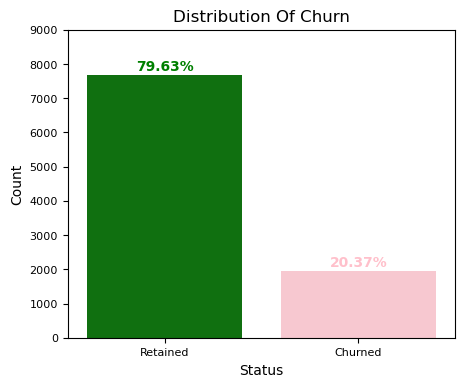

In [196]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.countplot(x = 'churn', data=df, palette=colors, ax=ax)

for index, value in enumerate(df['churn'].value_counts()):
    label = '{}%'.format(round((value / df['churn'].shape[0]) * 100, 2))
    ax.annotate(label,
                xy = (index, value + 250),
                ha = 'center',
                va = 'center',
                color = colors[index],
                fontweight = 'bold',
                size = font_size)

ax.set_xticklabels(['Retained', 'Churned'])
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.set_title('Distribution Of Churn')
ax.set_ylim([0, 9000]);

In [197]:
categorical = ['country', 'gender', 'tenure', 'products_number', 'credit_card', 'active_member']

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'estimated_salary'}>],
       [<Axes: title={'center': 'balance'}>,
        <Axes: title={'center': 'credit_score'}>]], dtype=object)

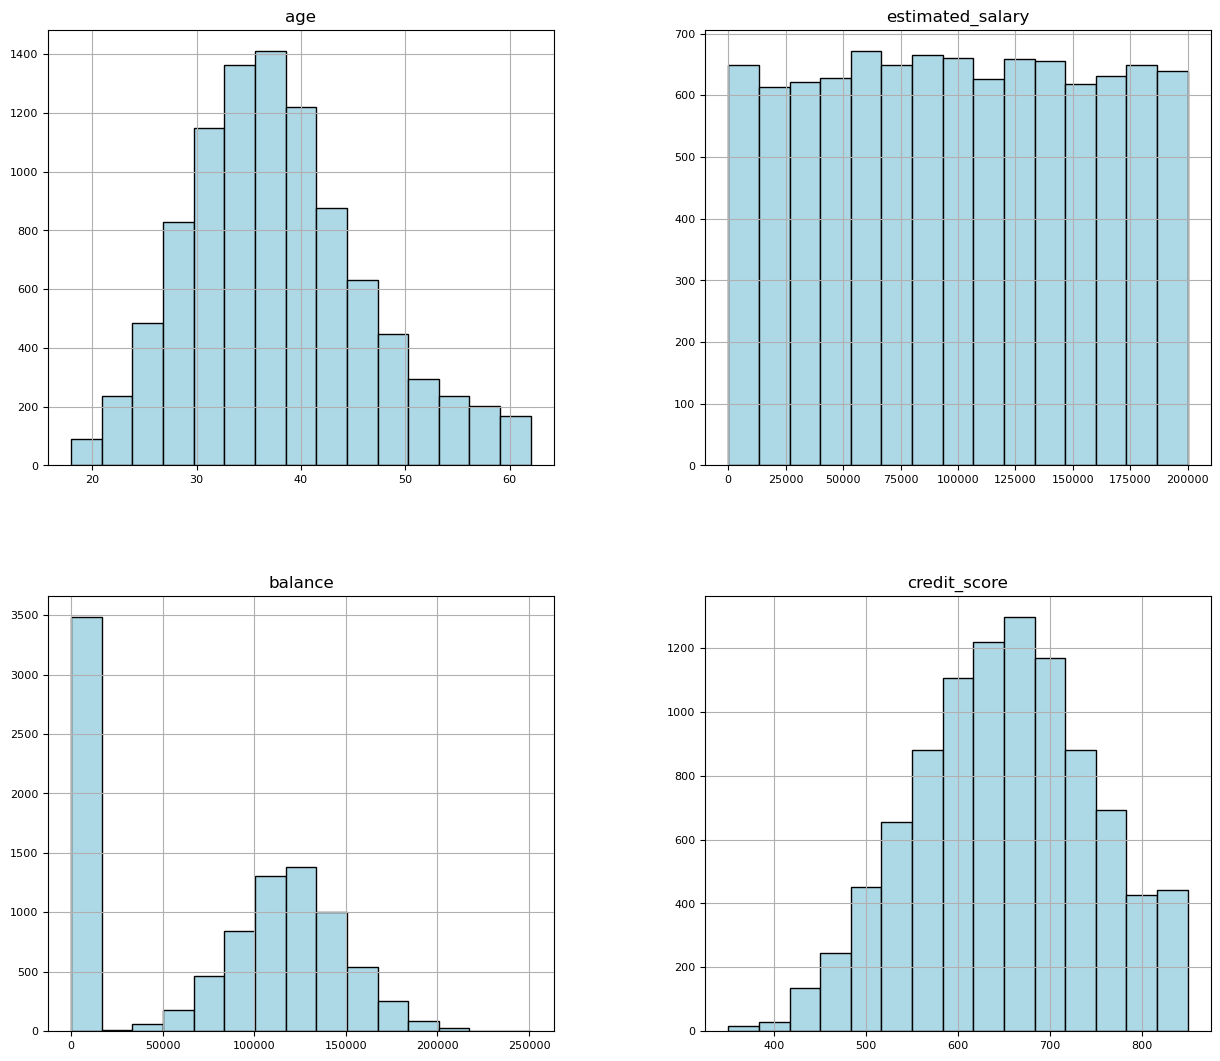

In [198]:
df[cols].hist(figsize=(15, 13),
              bins=15,
              layout=(2, 2),
              color='lightblue',
              edgecolor='black',
              linewidth=1.0)

In [199]:
df[cols].corr()

,age,estimated_salary,balance,credit_score
age,1.000000,-0.004559,0.041216,-0.015989
estimated_salary,-0.004559,1.000000,0.010537,-0.000493
balance,0.041216,0.010537,1.000000,0.006396
credit_score,-0.015989,-0.000493,0.006396,1.000000


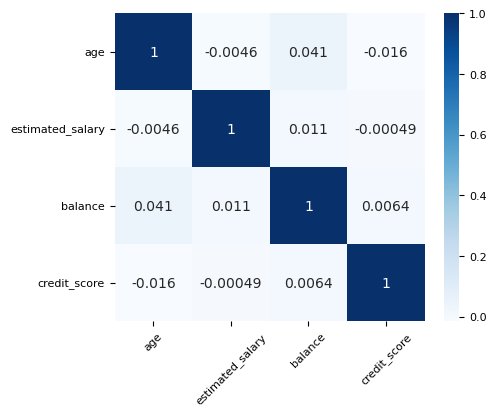

In [200]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.heatmap(df[cols].corr(),
            annot = True,
            annot_kws={'fontsize': 10},
            cmap = 'Blues',
            ax = ax)

ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=360)

In [201]:
def plot(df, feature):
    # Make a copy to avoid modifying the original dataframe
    df_func = df.copy()
    
    # Convert churn to categorical if it's not already
    df_func['churn'] = df_func['churn'].astype('category')
    
    # Split the data based on churn status
    df_churned = df_func[df_func['churn'] == 1]
    df_retained = df_func[df_func['churn'] == 0]
    
    # Create the figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2,
                                    figsize=(9, 7),
                                    sharex=True,
                                    gridspec_kw={'height_ratios': (0.7, 0.3)})
    
    colors = ['#1f77b4', '#ff7f0e']
    
    # Top plot: histograms for retained vs churned
    for sub_df, color, label in zip([df_retained, df_churned], colors, ['Retained', 'Churned']):
        sns.histplot(data=sub_df,
                    x=feature,
                    bins=15,
                    color=color,
                    alpha=0.6,
                    edgecolor='firebrick',
                    label=label,
                    kde=False,
                    ax=ax1)
    
    ax1.legend()
    ax1.set_ylabel('Frequency')
    ax1.set_title(f'Distribution of {feature} by Churn Status')
    
    # Bottom plot: boxplots
    sns.boxplot(x=feature, y='churn', data=df_func, palette=colors, ax=ax2)
    ax2.set_ylabel('')
    ax2.set_yticklabels(['Retained', 'Churned'])
    ax2.set_xlabel(feature.capitalize())
    
    plt.tight_layout()
    plt.show()

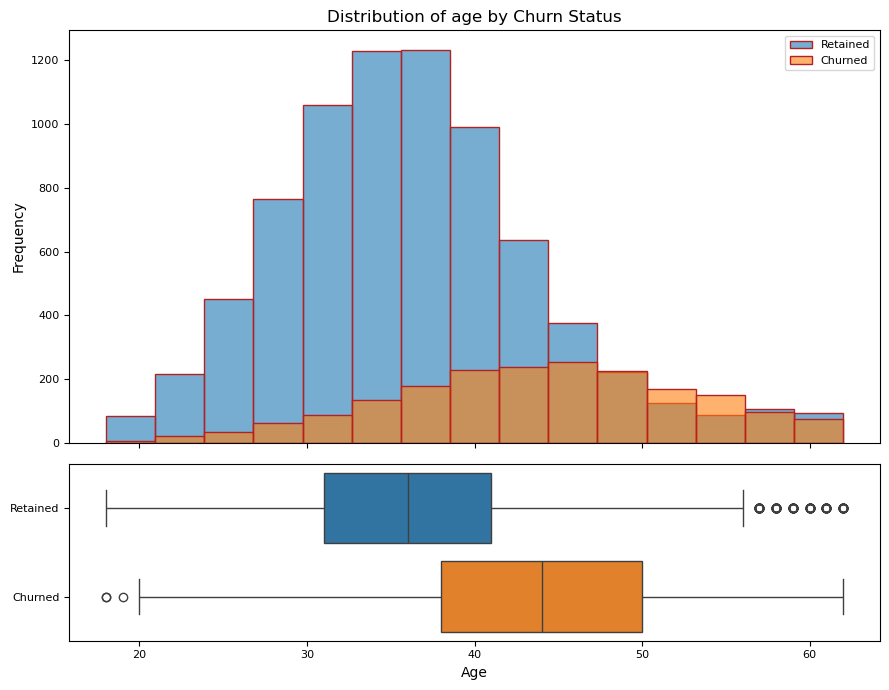

In [202]:
plot(df, 'age')

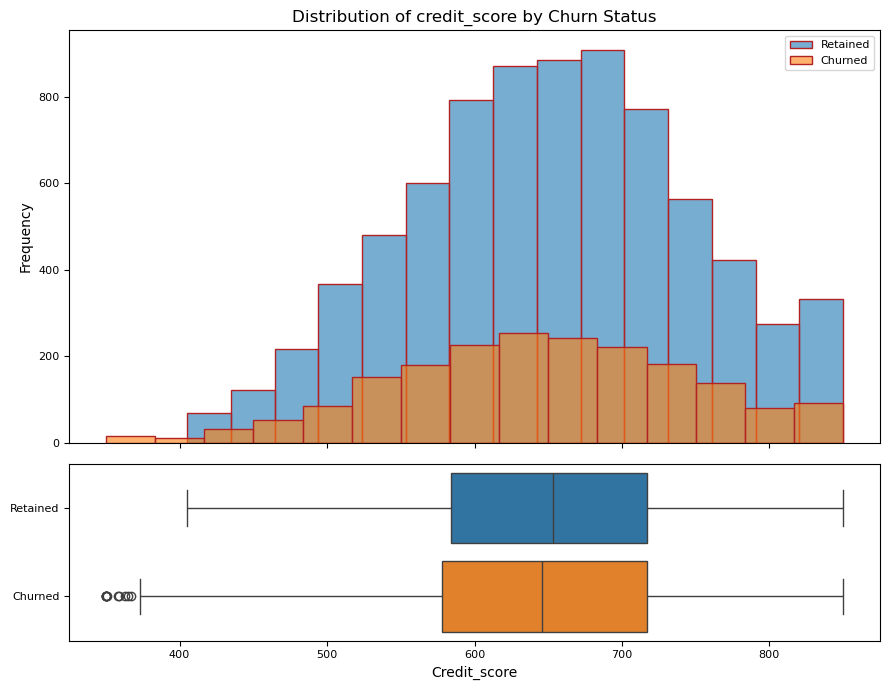

In [203]:
plot(df, 'credit_score')

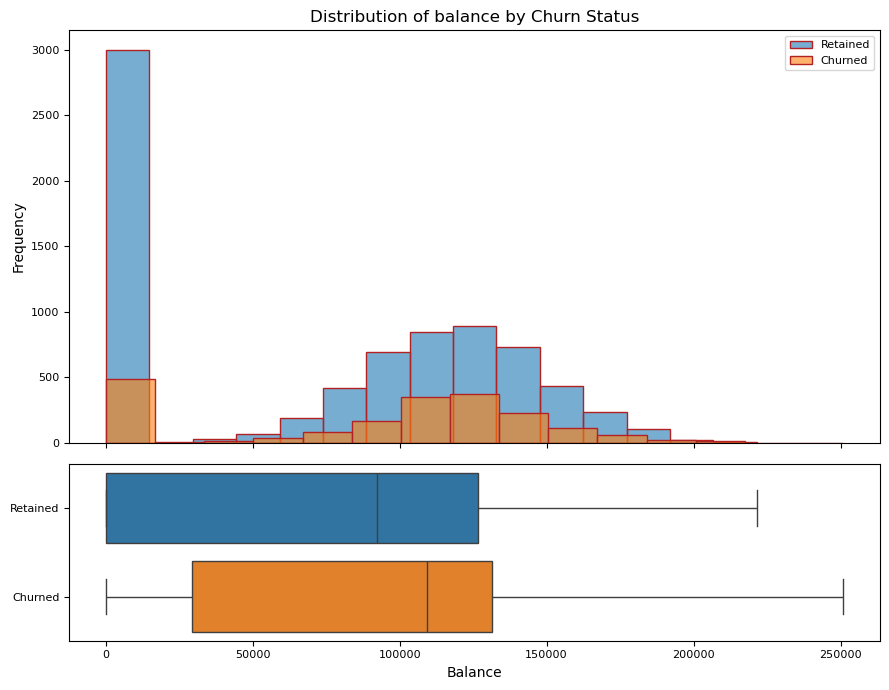

In [204]:
plot(df, 'balance')

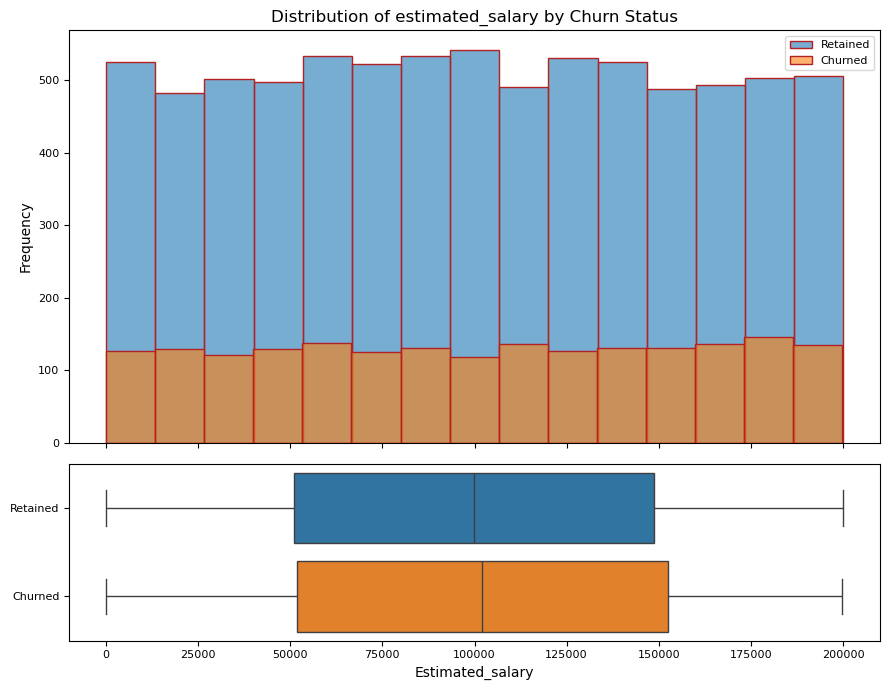

In [205]:
plot(df, 'estimated_salary')

In [206]:
font_size = 16
plt.rcParams['axes.labelsize'] = font_size
plt.rcParams['axes.titlesize'] = font_size + 2
plt.rcParams['xtick.labelsize'] = font_size - 2
plt.rcParams['ytick.labelsize'] = font_size -2
plt.rcParams['legend.fontsize'] = font_size - 2

colors_cat = ['cyan', 'steelblue', 'seagreen', 'black', 'darkorange', 'purple', 'firebrick', 'slategrey', 'red', 'yellow', 'pink']

In [207]:
categorical

['country',
 'gender',
 'tenure',
 'products_number',
 'credit_card',
 'active_member']

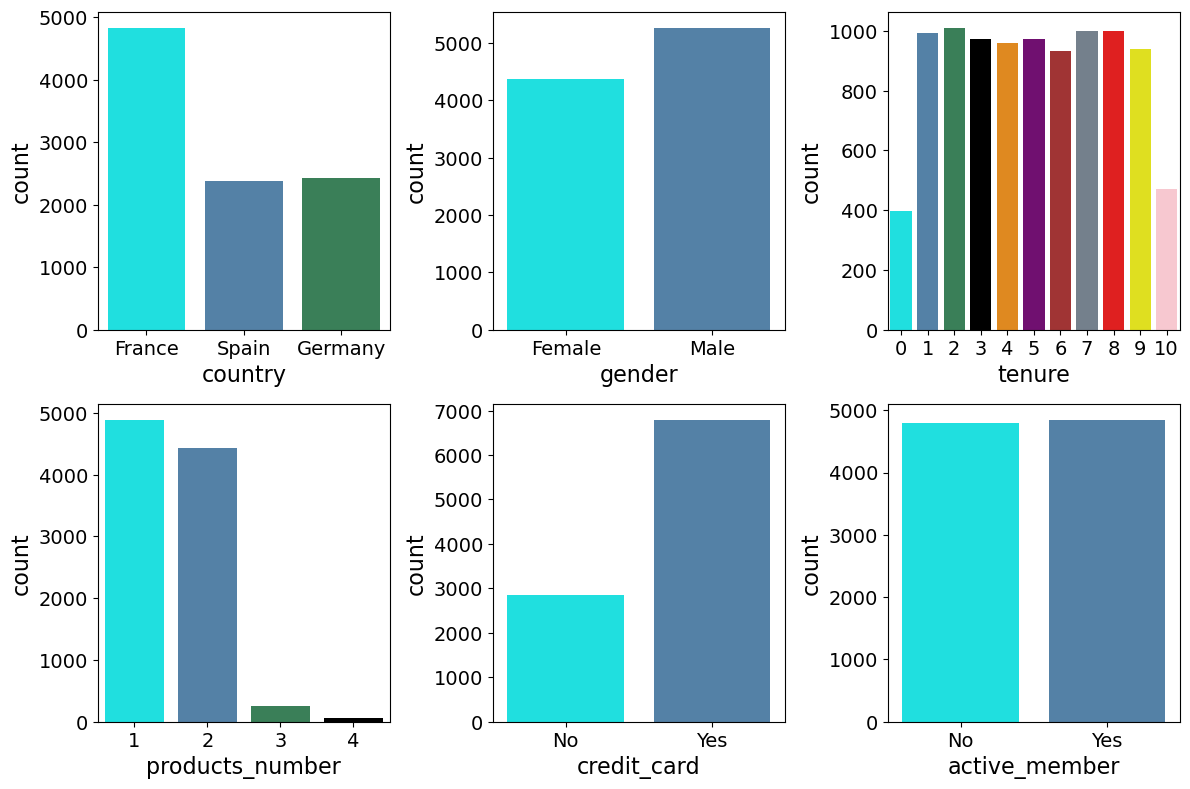

In [208]:
df_cat = df[categorical]
fix, ax = plt.subplots(2, 3, figsize=(12, 8))

for index, column in enumerate(df_cat.columns):

    plt.subplot(2, 3, index + 1)
    sns.countplot(x=column, data=df, palette=colors_cat)

    plt.ylabel('count')
    if (column == 'credit_card' or column == 'active_member'):
        plt.xticks([0, 1], ['No', 'Yes'])

plt.tight_layout()

In [209]:
df = df.drop(['tenure', 'credit_card', 'estimated_salary'], axis=1)

In [210]:
df.head()

,credit_score,country,gender,age,balance,products_number,active_member,churn
0,619,France,Female,42,0.00,1,1,1
1,608,Spain,Female,41,83807.86,1,1,0
2,502,France,Female,42,159660.80,3,0,1
3,699,France,Female,39,0.00,2,0,0
4,850,Spain,Female,43,125510.82,1,1,0


In [211]:
from sklearn.model_selection import train_test_split

In [212]:
X = df.drop(columns=['churn'])
y = df['churn']

In [213]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=df['churn'])

In [214]:
print("X_train shape :", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape : (7712, 7)
X_test shape : (1929, 7)
y_train shape : (7712,)
y_test shape : (1929,)


In [215]:
y_test.value_counts()

churn
0    1536
1     393
Name: count, dtype: int64

In [216]:
df['gender'].value_counts()

gender
Male      5265
Female    4376
Name: count, dtype: int64

In [217]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [218]:
X_train['gender'].value_counts()

gender
Male      4210
Female    3502
Name: count, dtype: int64

In [219]:
X_train['gender'] = le.fit_transform(X_train['gender'])

In [220]:
X_test['gender'] = le.fit_transform(X_test['gender'])

In [221]:
X_train['gender']

9185    1
3242    0
3536    1
9544    0
742     1
       ..
555     0
3318    0
6299    1
9889    0
2942    0
Name: gender, Length: 7712, dtype: int64

In [222]:
df.head(10)

,credit_score,country,gender,age,balance,products_number,active_member,churn
0,619,France,Female,42,0.00,1,1,1
1,608,Spain,Female,41,83807.86,1,1,0
2,502,France,Female,42,159660.80,3,0,1
3,699,France,Female,39,0.00,2,0,0
4,850,Spain,Female,43,125510.82,1,1,0
5,645,Spain,Male,44,113755.78,2,0,1
6,822,France,Male,50,0.00,2,1,0
7,376,Germany,Female,29,115046.74,4,0,1
8,501,France,Male,44,142051.07,2,1,0
9,684,France,Male,27,134603.88,1,1,0


In [223]:
def country_conversion(df):
    df['country'] = df['country'].map({
        'Germany' : 1,
        'Spain' : 0,
        'France' : 0
    })
    return df

In [224]:
X_train = country_conversion(X_train)

In [225]:
X_train['country'].value_counts()

country
0    5794
1    1918
Name: count, dtype: int64

In [226]:
X_test['country'].value_counts()

country
France     965
Germany    507
Spain      457
Name: count, dtype: int64

In [227]:
X_test = country_conversion(X_test)

In [228]:
X_test['country'].value_counts()

country
0    1422
1     507
Name: count, dtype: int64

In [229]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scl_columns = ['credit_score', 'age', 'balance']
X_train[scl_columns] = scaler.fit_transform(X_train[scl_columns])

In [230]:
X_test[scl_columns] = scaler.transform(X_test[scl_columns])

In [231]:
X_test.describe()

,credit_score,country,gender,age,balance,products_number,active_member
count,1929.000000,1929.000000,1929.000000,1929.000000,1929.000000,1929.000000,1929.000000
mean,-0.008112,0.262830,0.546916,0.017352,0.017052,1.526179,0.507517
std,0.985561,0.440285,0.497923,0.998555,1.014106,0.549862,0.500073
min,-3.098335,0.000000,0.000000,-2.244194,-1.226998,1.000000,0.000000
25%,-0.685213,0.000000,0.000000,-0.654271,-1.226998,1.000000,0.000000
50%,0.026348,0.000000,1.000000,-0.086441,0.358094,2.000000,1.000000
75%,0.655410,1.000000,1.000000,0.594955,0.842045,2.000000,1.000000
max,2.057908,1.000000,1.000000,2.752708,2.185110,4.000000,1.000000


In [232]:
from imblearn.over_sampling import SMOTE

In [233]:
over = SMOTE(sampling_strategy='auto', random_state=42)
X_train, y_train = over.fit_resample(X_train, y_train)

print(y_train.value_counts())

churn
0    6141
1    6141
Name: count, dtype: int64


In [234]:
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [235]:
scoring_metric = 'accuracy'

In [236]:
clf_list = [('Logistic Regression', LogisticRegression(random_state=42))]

cv_base_mean, cv_std = [], []

for clf in clf_list:
    cv = cross_val_score(
        estimator=clf[1],
        X=X_train,
        y=y_train,
        scoring=scoring_metric,
        cv=5,
        n_jobs=-1
    )

    cv_base_mean.append(cv.mean())
    cv_std.append(cv.std())

print('Baseline Models (Recall) :')

for i in range(len(clf_list)):
    print('     {}: {}'.format(clf_list[i][0], np.round(cv_base_mean[i], 2)))

Baseline Models (Recall) :
     Logistic Regression: 0.72


In [237]:
clf_list = [
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42))
]

In [238]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, auc, roc_auc_score, roc_curve, classification_report


In [239]:
lr = LogisticRegression(random_state=42)

param_grid = {
    'max_iter' : [100],
    'penalty' : ['l1', 'l2'],
    'C' : [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'solver' : ['lbfgs', 'libinear']
}

lr_clf = GridSearchCV(estimator=lr,
                      param_grid = param_grid,
                      scoring = scoring_metric,
                      cv = 5,
                      verbose = False,
                      n_jobs = -1)

best_lr_clf = lr_clf.fit(X_train, y_train)

In [240]:
best_lr_clf.best_estimator_

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` 

In [241]:
lr_best = LogisticRegression(C=0.001, penalty='l1', random_state=42, solver='liblinear')

In [242]:
lr_best.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.001
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [243]:
y_train_lr_pred = lr_best.predict(X_train)

In [244]:
print(classification_report(y_train, y_train_lr_pred))

              precision    recall  f1-score   support

           0       0.72      0.60      0.65      6141
           1       0.66      0.77      0.71      6141

    accuracy                           0.68     12282
   macro avg       0.69      0.68      0.68     12282
weighted avg       0.69      0.68      0.68     12282



In [245]:
y_test_lr_pred = lr_best.predict(X_test)

In [246]:
print(classification_report(y_test, y_test_lr_pred))

              precision    recall  f1-score   support

           0       0.91      0.61      0.73      1536
           1       0.34      0.76      0.47       393

    accuracy                           0.64      1929
   macro avg       0.62      0.69      0.60      1929
weighted avg       0.79      0.64      0.68      1929



In [247]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [248]:
rf = RandomForestClassifier()
param_grid = {
    'n_estimators' : [100, 150],
    'criterion' : ['entropy', 'gini'],
    'bootstrap' : [True, False],
    'max_depth' : [4, 5, 6],
    'max_features' : ['auto', 'sqrt'],
    'min_samples_leaf' : [2, 3, 5],
    'min_samples_split' : [2, 3, 5]
}

rf_clf = GridSearchCV(estimator=rf,
                      param_grid = param_grid,
                      scoring = 'f1',
                      cv = 5,
                      verbose = False,
                      n_jobs = -1)

best_lr_clf = rf_clf.fit(X_train, y_train)

In [249]:
best_lr_clf.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [250]:
best_lr_clf.best_params_

{'bootstrap': True,
 'criterion': 'gini',
 'max_depth': 6,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 100}

In [251]:
rfc = RandomForestClassifier(bootstrap=False, max_depth=6, min_samples_leaf=2, min_samples_split=3, n_estimators=150)

In [252]:
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [253]:
y_train_pred_rf = rfc.predict(X_train)

In [254]:
print("Random Forest Classifier on y train")
print(classification_report(y_train, y_train_pred_rf))

Random Forest Classifier on y train
              precision    recall  f1-score   support

           0       0.79      0.83      0.81      6141
           1       0.82      0.77      0.80      6141

    accuracy                           0.80     12282
   macro avg       0.80      0.80      0.80     12282
weighted avg       0.80      0.80      0.80     12282



In [255]:
y_test_pred_rf = rfc.predict(X_test)

In [256]:
print("Random Forest Classifier on y test")
print(classification_report(y_test, y_test_pred_rf))

Random Forest Classifier on y test
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      1536
           1       0.54      0.72      0.62       393

    accuracy                           0.82      1929
   macro avg       0.73      0.78      0.75      1929
weighted avg       0.84      0.82      0.83      1929



In [257]:
gbc = GradientBoostingClassifier()
param_grid = {
    'n_estimators' : [600],
    'subsample' : [0.66, 0.75],
    'learning_rate' : [0.001, 0.01],
    'max_depth' : [3, 4, 5],
    'min_samples_split' : [5, 7, 10],
    'min_samples_leaf' : [3, 5, 7],
    'max_features' : ['auto', 'log2', None],
    'n_iter_no_change' : [20],
    'validation_fraction' : [0.2],
    'tol' : [0.01]
}

gbc_clf = GridSearchCV(estimator=gbc,
                       param_grid = param_grid,
                       scoring = 'f1',
                       cv = 5,
                       verbose = False,
                       n_jobs = -1)

best_gbc_clf = gbc_clf.fit(X_train, y_train)

In [258]:
best_gbc_clf.best_params_

{'learning_rate': 0.01,
 'max_depth': 5,
 'max_features': None,
 'min_samples_leaf': 3,
 'min_samples_split': 7,
 'n_estimators': 600,
 'n_iter_no_change': 20,
 'subsample': 0.75,
 'tol': 0.01,
 'validation_fraction': 0.2}

In [259]:
best_gbc_clf.best_estimator_

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",600
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.75
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``

In [260]:
gbc = GradientBoostingClassifier(learning_rate=0.01, max_depth=5, min_samples_leaf=7, min_samples_split = 7, 
                                n_estimators = 600, n_iter_no_change=20, subsample=0.75, tol=0.01, 
                                validation_fraction=0.2)

In [261]:
gbc.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",600
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.75
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",7
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",7
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``

In [262]:
y_train_gbc_pred = gbc.predict(X_train)

In [263]:
print("Gradient Boosting Classifier on y train")
print(classification_report(y_train, y_train_gbc_pred))

Gradient Boosting Classifier on y train
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      6141
           1       0.84      0.83      0.84      6141

    accuracy                           0.84     12282
   macro avg       0.84      0.84      0.84     12282
weighted avg       0.84      0.84      0.84     12282



In [264]:
y_test_gbc_pred = gbc.predict(X_test)


In [265]:
print("Gradient Boosting Classifier on y test")
print(classification_report(y_test, y_test_gbc_pred))


Gradient Boosting Classifier on y test
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1536
           1       0.56      0.73      0.64       393

    accuracy                           0.83      1929
   macro avg       0.74      0.79      0.76      1929
weighted avg       0.85      0.83      0.84      1929



In [266]:
# best models are 1. Random Forest 2. Gradient Boosting